# Implementation of C-Mixup
This is the individual part for Nicolai Andersen

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataloader import default_collate

import pandas as pd
import numpy as np
import datetime
import random
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from typing import List, Optional
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Using device:", device)

Using device: cuda


## C-Mixup implementation

In [ ]:
class CMixup:
    """
    C-Mixup data augmentation for regression.

    Parameters
    ----------
    label_col : str
        Name of the target / label column in the DataFrame.
    sigma : float
        Gaussian kernel bandwidth sigma.  Larger sigma → closer to vanilla mixup
        (uniform sampling).  Smaller sigma → only very similar labels are mixed.
        The paper recommends choosing via cross-validation; a good starting
        point is the standard deviation of the label values.
    alpha : float
        Shape parameter for the Beta(alpha, alpha) distribution from which the
        interpolation ratio λ is sampled.  alpha = 0.2 is a common default.
    ratio_of_samples : float
        Ratio of how many samples are taken from training data when creating
        new synthetic samples.
    include_original : bool
        If True (default) the returned DataFrame contains the original rows
        followed by the synthetic rows.
    seed : int or None
        Random seed for reproducibility.
    tensor_cols : list[str] or None
        Explicit list of columns that contain torch.Tensor / np.ndarray
        objects.  If None the class auto-detects them from the first row.
    categorical_cols : list[str] or None
        Explicit list of categorical columns.  If None the class
        auto-detects object / Categorical dtype columns.
    """

    def __init__(
        self,
        label_col: str,
        sigma: float = 1.0,
        alpha: float = 0.2,
        ratio_of_samples: int = 1,
        include_original: bool = False,
        seed: Optional[int] = None,
        tensor_col: str = None,
        categorical_cols: List[str] = None,
        numeric_cols: List[str] = None,
    ):
        if sigma <= 0: raise ValueError("sigma must be positive")
        if alpha <= 0: raise ValueError("alpha must be positive")
        if 1.0 < ratio_of_samples < 0.0: raise ValueError("ratio_of_samples must be <= 1.0 and >= 0.0")

        self.label_col = label_col
        self.sigma = sigma
        self.alpha = alpha
        self.ratio_of_samples = ratio_of_samples
        self.include_original = include_original
        self.seed = seed
        self._tensor_col = tensor_col
        self._cat_cols = categorical_cols
        self._num_cols = numeric_cols
        
        # Set after fit()
        self._sampling_probs: Optional[np.ndarray] = None   # (N, N)
        self._df_fit: Optional[pd.DataFrame] = None

    def interpolate_datapoints(
        self,
        a: pd.Series,
        b: pd.Series,
        lam: float
    ) -> pd.Series:
        """
        Interpolate two datapoints and all their values according to their type.

        numeric / tensor = lam*a + (1-lam)*b
        categorical = a if lam >= 0.5 else b
        """
        c = pd.Series()
        keys = a.keys()
        numeric_cols = [col for col in self._num_cols if col in keys]
        categorical_cols = [col for col in self._cat_cols if col in keys]
        
        for col in numeric_cols:
            c[col] = lam * a[col] + (1 - lam) * b[col]

        for col in categorical_cols:
            c[col] = a[col] if lam >= 0.5 else b[col]

        c_path = "C-Mixup/" + a[self._tensor_col][:-3] + '_' + b[self._tensor_col][:-3] + '.pt'
        c[self._tensor_col] = c_path
        tensor = torch.lerp(self.tensor_dict[b[self._tensor_col]], self.tensor_dict[a[self._tensor_col]], lam)

        c[self.label_col] = lam * a[self.label_col] + (1 - lam) * b[self.label_col]
        
        return c, tensor

    def get_sampling_probs(self) -> np.ndarray:
        """
        Build an NxN matrix of sampling probabilities

        P[i, j] = softmax_j( -||y_i - y_j||**2 / (2 * sigma ** 2))
        """
        if self.label_col not in self.df.columns: raise ValueError(f"label_col '{self.label_col}' not found in DataFrame")

        y_array = self.df[self.label_col].to_numpy().reshape(-1, 1)
        sq_norms = np.sum(y_array ** 2, axis=1, keepdims=True) # (n, 1)
        dists_sq = sq_norms + sq_norms.T - 2.0 * (y_array @ y_array.T)
        dists_sq = np.clip(dists_sq, 0.0, None)

        log_probs = -dists_sq / (2.0 * self.sigma ** 2)
        np.fill_diagonal(log_probs, -np.inf) #Exclude self

        log_probs -= log_probs.max(axis=1, keepdims=True) # Subtract max per row
        probs = np.exp(log_probs)
        row_sums = probs.sum(axis=1, keepdims=True)
        probs /= row_sums

        return probs
    
    def fit(self, df: pd.DataFrame, tensor_dict: dict) -> "CMixup":
        """
        Compute and cache the label-similarity kernel on the training data.

        Parameters
        ----------
        df : pd.DataFrame
            Training data including the label column.
        tensor_dict : dict
            Dictionary mapping column names to tensor data.

        Returns
        -------
        self
        """
        self.df = df
        self.tensor_dict = tensor_dict
        self._sampling_probs = self.get_sampling_probs()
        self._df_fit = df.reset_index(drop=True)
        return self
    
    def transform(
            self,
            ratio_of_samples: Optional[float] = None,
    ):
        """
        Generate synthetic samples by C-Mixup interpolation.

        If called after fit() the *fitted* kernel is used (transductive
        mode – mixing is relative to the training set).  If df is the
        same object passed to fit() this is the standard in-distribution
        augmentation.

        Parameters
        ----------
        df : pd.DataFrame
            Data to augment (typically the training set).
        ratio_of_samples : float or None
            Override self.ratio_of_samples for this call.

        Returns
        -------
        pd.DataFrame
            Original rows (if include_original=True) followed by synthetic
            rows.  Index is reset.
        """
        if self._sampling_probs is None:
            raise RuntimeError("Call fit() before transform()")
        df = self.df
        ratio = ratio_of_samples if ratio_of_samples is not None else self.ratio_of_samples
        size = int(len(df) * ratio)
        rng = np.random.default_rng(self.seed)
        df = df.reset_index(drop=True)

        #Sampling batch from training data
        batch_indices = rng.choice(len(df), size=size, replace=False)
        lambdas = rng.beta(self.alpha, self.alpha, size=size)

        synthetic_rows = []
        synthetic_tensor_dict = {}

        for idx, i in enumerate(batch_indices):
            lam = float(lambdas[idx])
            
            # Drawing mixing partner j
            probs_i = self._sampling_probs[i]

            j = int(rng.choice(len(probs_i), p=probs_i))
            
            row_i = df.iloc[i]
            row_j = self._df_fit.iloc[j]


            # Interpolate features
            new_row, new_tensor = self.interpolate_datapoints(
                row_i,
                row_j,
                lam
            )
            synthetic_rows.append(new_row)
            synthetic_tensor_dict[new_row[self._tensor_col]] = new_tensor


        df_synthetic = pd.DataFrame(synthetic_rows, columns=df.columns)

        return df_synthetic.reset_index(drop=True), synthetic_tensor_dict
    
    def fit_transform(self, df: pd.DataFrame, tensor_dict: dict):
        """Fit on df and immediately return the augmented DataFrame."""
        return self.fit(df, tensor_dict).transform(df, tensor_dict)

    def __repr__(self) -> str:
        fitted = self._sampling_probs is not None
        return (
            f"CMixup(label_col={self.label_col!r}, sigma={self.sigma}, "
            f"alpha={self.alpha}, ratio_of_samples={self.ratio_of_samples}, "
            f"fitted={fitted})"
        )

## Data

### Loading data

In [2]:
DataPath = Path("..") / "Processed data"
ImgPath = DataPath / "processed_composite"
ModelPath = Path("..") / "Models"

full_df = pd.read_csv(DataPath / "processed_data.csv")
japan_df = pd.read_csv(DataPath / "processed_japan.csv")
philippines_df = pd.read_csv(DataPath / "processed_philippines.csv")
eval_df = pd.read_csv(DataPath / "processed_eval.csv")

tensor_dict = {}
for img_file in ImgPath.glob("*.pt"):
    img_dict = torch.load(img_file, weights_only=True)
    tensor = torch.cat([img_dict['sentinel'], img_dict['viirs']], dim=0)
    tensor_dict[img_file.name] = tensor

print("Data loaded")

Data loaded


### Relevant columns
Columns used in our data

In [3]:
numeric_cols = [
    'deflated_gdp_usd',
    'us_cpi',
    'straight_distance_to_capital_km',
    'quarter_label'
]

categorical_cols = [
    "geolocation_name",
    "country",
    "landlocked",
    "region_economic_classification",
    "access_to_airport",
    "access_to_port",
    "access_to_highway",
    "access_to_railway",
    "seismic_hazard_zone",
    "flood_risk_class",
    "tropical_cyclone_wind_risk",
    "tornadoes_wind_risk",
    "koppen_climate_zone",
]

target_col = 'construction_cost_per_m2_usd'

img_col = "processed_imgs"

id_col = "data_id"

### Helper dataset class
Helps to convert the data into tensors the model can load

In [4]:
class ConstructionDataset(Dataset):
    """
    Loads one row at a time from the CSV and lazily loads the matching
    .pt tensor file from tensor_dict.

    Args:
        df:             pandas DataFrame (already split into train/val)
        tensor_dict:    directory containing image tensors of size (13, H, W)
        augment:        whether to apply random horizontal/vertical flips
    """

    def __init__(
        self,
        df: pd.DataFrame,
        tensor_dict: dict,
        augment: bool = False,
    ):
        self.df = df.reset_index(drop=True)
        self.tensor_dict = tensor_dict
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        data_id = row[id_col]
        continuous = torch.tensor(row[numeric_cols].values.astype(np.float32), dtype=torch.float32)
        categoricals = {name: torch.tensor(int(row[name]), dtype=torch.long) for name in categorical_cols if name in self.df.columns}
        images = self.tensor_dict[row[img_col]]
        if target_col in self.df.columns:
            target = torch.tensor(row[target_col], dtype=torch.float32)
        else: 
            target = torch.tensor(np.nan, dtype=torch.float32)

        if self.augment:
            if torch.rand(1) > 0.5:
                images = torch.flip(images, dims=[2])    # horizontal flip
            if torch.rand(1) > 0.5:
                images = torch.flip(images, dims=[1])    # vertical flip

        return data_id, continuous, categoricals, images, target

## Model Definition

### Multimodal Construction Cost Predictor

#### Tabular Encoder

In [6]:
class TabularEncoder(nn.Module):
    """
    Embeds categorical features + passes continuous features through MLP.
    Output: fixed 128-d vector.
    """

    def __init__(
        self,
        continuous_dim: int,
        categorical_vocab: dict,
        embed_dim_fn=lambda v: min(50, (v + 1) // 2),
        hidden_dim: int = 256,
        out_dim: int = 128,
        dropout: float = 0.3,
    ):
        super().__init__()

        self.embeddings = nn.ModuleDict({
            name: nn.Embedding(vocab_size + 1, embed_dim_fn(vocab_size))
            for name, vocab_size in categorical_vocab.items()
        })

        total_embed_dim = sum(embed_dim_fn(v) for v in categorical_vocab.values())
        mlp_in = continuous_dim + total_embed_dim

        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, out_dim),
            nn.ReLU(),
        )

    def forward(self, continuous: torch.Tensor, categoricals: dict) -> torch.Tensor:
        """
        Args:
            continuous:   (B, continuous_dim)  float32, already standardised
            categoricals: dict of {name: (B,) int64 tensors}
        Returns:
            (B, out_dim)
        """
        parts = [continuous]
        for name, emb in self.embeddings.items():
            parts.append(emb(categoricals[name]))
        x = torch.cat(parts, dim=1)
        return self.mlp(x)

#### Lightweight CNN image encoder

In [7]:
class ResBlock(nn.Module):
    """Simple pre-activation residual block."""

    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
        )

    def forward(self, x):
        return x + self.block(x)

class ImageEncoder(nn.Module):
    """
    Small CNN for 13-channel (Sentinel-2 + VIIRS) imagery at 224x224.
    Projects to a low-dimensional vector (default 64-d) to avoid
    dominating the tabular signal at fusion time.

    Deliberately kept shallow (3 stages) to reduce overfitting on a
    small dataset (1024 samples) and to keep image embedding compact.
    """

    def __init__(
        self,
        in_channels: int = 13, #1 for VIIRS and 12 for Sentinel
        base_ch: int = 32,
        out_dim: int = 64,
        dropout: float = 0.3,
    ):
        super().__init__()

        # Stage 1: 224 -> 56  (4x stride)
        self.stage1 = nn.Sequential(
            nn.Conv2d(in_channels, base_ch, kernel_size=7, stride=4, padding=3, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(),
            ResBlock(base_ch),
        )
        # Stage 2: 56 -> 14  (4x stride via 2 poolings)
        self.stage2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(),
            ResBlock(base_ch * 2),
            nn.Conv2d(base_ch * 2, base_ch * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(),
            ResBlock(base_ch * 2),
        )
        # Stage 3: 14 -> 7
        self.stage3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(),
            ResBlock(base_ch * 4),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)   # -> (B, C, 1, 1)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(base_ch * 4, out_dim),
            nn.ReLU(),
        )

    def forward(self, imgs: torch.Tensor) -> torch.Tensor:
        """
        Args:
            imgs: (B, 13, H, W)  float32, channel order: sentinel[0:12] + viirs[12]
        Returns:
            (B, out_dim)
        """
        x = self.stage1(imgs)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

#### Gated fusion

In [8]:
class GatedFusion(nn.Module):
    """
    Learns a per-sample gate vector in [0,1]^d that blends the two
    modality embeddings.  The gate is computed from the concatenation
    of both embeddings, so it can route information context-dependently.

    Output dimension = out_dim (tabular projected up, image projected up/down).
    """

    def __init__(self, tab_dim: int = 128, img_dim: int = 64, out_dim: int = 128):
        super().__init__()
        self.out_dim = out_dim

        # Project both modalities to a common dimension
        self.tab_proj = nn.Linear(tab_dim, out_dim)
        self.img_proj = nn.Linear(img_dim, out_dim)

        # Gate: sigmoid output in (0,1)^out_dim
        self.gate_net = nn.Sequential(
            nn.Linear(tab_dim + img_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
            nn.Sigmoid(),
        )

    def forward(self, tab: torch.Tensor, img: torch.Tensor) -> torch.Tensor:
        """
        Args:
            tab: (B, tab_dim)
            img: (B, img_dim)
        Returns:
            (B, out_dim)
        """
        gate  = self.gate_net(torch.cat([tab, img], dim=1))   # (B, out_dim)
        tab_p = self.tab_proj(tab)                            # (B, out_dim)
        img_p = self.img_proj(img)                            # (B, out_dim)
        return gate * tab_p + (1 - gate) * img_p

#### Full multimodal model

In [9]:
class ConstructionCostModel(nn.Module):
    """
    End-to-end model:
      tabular features + satellite imagery  ->  construction cost per m2

    Modality balance
    ----------------
    - Tabular encoder produces 128-d, image encoder 64-d.
    - GatedFusion projects both to 128-d with a learned gate, so the
      network can suppress image noise when tabular features are
      sufficient and boost image contribution when helpful.
    - Result: tabular signal has double the raw dimensionality before
      fusion, preventing the high-capacity CNN from dominating.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        tab_out_dim: int = 128,
        img_out_dim: int = 64,
        fusion_dim: int = 128,
        head_hidden: int = 64,
        dropout: float = 0.3,
        img_channels: int = 13,
    ):
        super().__init__()

        cols = df.columns

        continuous_dim = 0
        for num_col in numeric_cols:
            if num_col in cols:
                continuous_dim += 1
        categorical_vocab = {}
        for cat_col in categorical_cols:
            if cat_col in cols:
                categorical_vocab[cat_col] = int(df[cat_col].max())
        
        self.tabular_encoder = TabularEncoder(
            continuous_dim = continuous_dim,
            categorical_vocab = categorical_vocab,
            out_dim = tab_out_dim,
            dropout = dropout,
        )
        self.image_encoder = ImageEncoder(
            in_channels = img_channels,
            out_dim = img_out_dim,
            dropout = dropout,
        )
        self.fusion = GatedFusion(
            tab_dim = tab_out_dim,
            img_dim = img_out_dim,
            out_dim = fusion_dim,
        )
        self.regression_head = nn.Sequential(
            nn.Linear(fusion_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )

    def forward(
        self,
        continuous: torch.Tensor, # (B, continuous_dim)
        categoricals: dict, # {name: (B,) int64}
        images: torch.Tensor, # (B, 13, H, W)
    ) -> torch.Tensor:
        """Returns (B,) predicted construction cost."""
        tab = self.tabular_encoder(continuous, categoricals)
        img = self.image_encoder(images)
        fused = self.fusion(tab, img)
        return self.regression_head(fused).squeeze(1)

## Training

### Loss Function
The loss function used in the competition

In [10]:
def RMSLELoss(preds, targets):
    preds = torch.clamp(preds, min=0)
    log_diff = torch.log1p(preds) - torch.log1p(targets)
    return torch.sqrt(torch.mean(log_diff ** 2))

### Collate Function
Custom collate function so the dataloader can handle strings

In [11]:
def collate_fn(batch):
    data_ids = [item[0] for item in batch]
    continuous = default_collate([item[1] for item in batch])
    categoricals = default_collate([item[2] for item in batch])
    images = default_collate([item[3] for item in batch])
    targets = default_collate([item[4] for item in batch])
    return data_ids, continuous, categoricals, images, targets

### Training functions

In [12]:
def train_model(
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        scheduler: torch.optim.lr_scheduler,
        c: CMixup,
        val_loader: DataLoader,
        epochs: int
    ):
    train_losses = []
    val_losses = []
    best_model_state = None
    best_val_loss = float('inf')
    
    print(f'{datetime.datetime.now().time()}  |  Starting training...')
    for epoch in range(1, epochs + 1):
        synth_df, synth_dict = c.transform()
        train_loader = DataLoader(ConstructionDataset(synth_df, tensor_dict=synth_dict, augment=False), batch_size=64, shuffle=True, collate_fn=collate_fn)

        #Training
        model.train()
        total_loss = 0.0
        for _, continuous, categoricals, images, target in train_loader:
            continuous = continuous.to(device)
            categoricals = {k: v.to(device) for k, v in categoricals.items()}
            images = images.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            pred = model(continuous, categoricals, images)
            loss = RMSLELoss(pred, target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(target)

        avg_train_loss = total_loss / len(train_loader.dataset)

        train_losses.append(avg_train_loss)
        
        del train_loader, synth_df, synth_dict

        #Validation
        model.eval()
        val_loss = 0.0
        for _, continuous, categoricals, images, target in val_loader:
            with torch.no_grad():
                continuous = continuous.to(device)
                categoricals = {k: v.to(device) for k, v in categoricals.items()}
                images = images.to(device)
                target = target.to(device)
                pred = model(continuous, categoricals, images)
                loss = RMSLELoss(pred, target)
                val_loss += loss.item() * len(target)
                
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()

        if scheduler is not None: scheduler.step(avg_val_loss)

        if epoch in (1, epochs) or epoch % 10 == 0:
            print('{}  |  Epoch {}  |  Training loss {:.3f} |  Validation loss {:.3f}'.format(datetime.datetime.now().time(), epoch, avg_train_loss, avg_val_loss))
    
    return train_losses, val_losses, best_model_state, best_val_loss



### Training the models
Training with hyperparameter tuning

In [ ]:
#Hyperparameters to test

#C-Mixup
sigmas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0] #Gaussian kernel bandwidth for C-Mixup sampling probabilities
alphas = [0.2, 0.4, 0.6] #Shape parameter for the Beta distribution from which the interpolation ratio λ is sampled
ratios_of_samples = [0.4] #Ratio of how many samples are taken from training data when creating new synthetic samples

param_grid = list(product(sigmas, alphas, ratios_of_samples))

def hyperparameter_search(df, modelName, param_grid):

    best_loss = float('inf')
    tuned_val_losses = []

    count = 0
    amount = len(param_grid)
    for params in param_grid:
        count += 1

        sigma, alpha, ratios_of_samples = params
        
        train, val = train_test_split(df, test_size=0.2, random_state=SEED)

        print(f"Training {modelName} ({count}/{amount}) with shape {train.shape}")
        print(f"Parameters: sigma={sigma}, alpha={alpha}, ratio_of_samples={ratios_of_samples}")
        
        c = CMixup(
            label_col=target_col,
            sigma=sigma,
            alpha=alpha,
            ratio_of_samples=ratios_of_samples,
            include_original=True,
            seed=42,
            tensor_col=img_col,
            categorical_cols=categorical_cols,
            numeric_cols=numeric_cols,
        ).fit(train, tensor_dict)

        val_dataset = ConstructionDataset(val, tensor_dict)
        val_loader = DataLoader(val_dataset, 128, shuffle=False, collate_fn=collate_fn)

        model = ConstructionCostModel(df).to(device)
        optimizer = torch.optim.AdamW(model.parameters())
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min')

        train_losses, val_losses, best_model_state, best_val_loss = train_model(model, optimizer, scheduler, c, val_loader, epochs=50)
        tuned_val_losses.append(val_losses)

        if best_val_loss <= best_loss:
            best_model = best_model_state
            best_loss = best_val_loss
            best_params = params
            best_train_losses = train_losses
            best_val_losses = val_losses
            best_train = train

        del model, optimizer, scheduler, c, val_loader, val_dataset
        torch.cuda.empty_cache()
    
    params_losses = list(zip(param_grid, tuned_val_losses))

    torch.save({
        'model': best_model,
        'best_loss': best_loss,
        'best_params' : best_params,
        'train_losses': best_train_losses,
        'val_losses': best_val_losses,
        'params_losses': params_losses,
        'training_data': best_train,
        'validation_data': val
    }, ModelPath / f"{modelName}.pth")

#Uncomment the following lines to retrain the models. Othersise, the pre-trained models will be loaded from the Models directory.
hyperparameter_search(full_df, "C-Mixup_full_model", param_grid)
hyperparameter_search(japan_df, "C-Mixup_japan_model", param_grid)
hyperparameter_search(philippines_df, "C-Mixup_philippines_model", param_grid)

## Evaluation
Evaluating which solution is better, full model or split model.

In [4]:
def evaluate_models(modelNames):
    for modelName in modelNames:
        checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=False)
        best_loss = checkpoint['best_loss']
        params = checkpoint['best_params']
        validation_losses = checkpoint['val_losses']
        print(f"{modelName}, Best loss: {best_loss}, Params: {params}")
        epoch = 1
        for loss in validation_losses:
            if loss == best_loss: 
                print(f"Best performance achieved in epoch: {epoch}")
                break
            epoch += 1
        print()
    #Calculate the combined performance of models
    if len(modelNames) > 1:
        lengths = []
        losses = []
        for modelName in modelNames:
            checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=False)
            length = len(checkpoint['validation_data'])
            loss = checkpoint['best_loss']
            lengths.append(length)
            losses.append(loss)
        combined_loss = sum(length * loss for length, loss in zip(lengths, losses)) / sum(lengths)
        print(f"Combined loss of models {modelNames}: {combined_loss}")

evaluate_models(["C-Mixup_full_model"])
evaluate_models(["C-Mixup_japan_model", "C-Mixup_philippines_model"])

C-Mixup_full_model, Best loss: 0.3567520747824413, Params: (0.01, 0.4, 0.4)
Best performance achieved in epoch: 32

C-Mixup_japan_model, Best loss: 0.13705769181251526, Params: (2.0, 0.4, 0.4)
Best performance achieved in epoch: 50

C-Mixup_philippines_model, Best loss: 0.3120839595794678, Params: (2.0, 0.6, 0.4)
Best performance achieved in epoch: 35

Combined loss of models ['C-Mixup_japan_model', 'C-Mixup_philippines_model']: 0.21522476285406686


### Plots
Plotting training and validation loss during training for each model, and best performance per sigma and alpha combination.
Keep in mind that the crossed out points are outliers that have been interpolated over to make the graph more readable

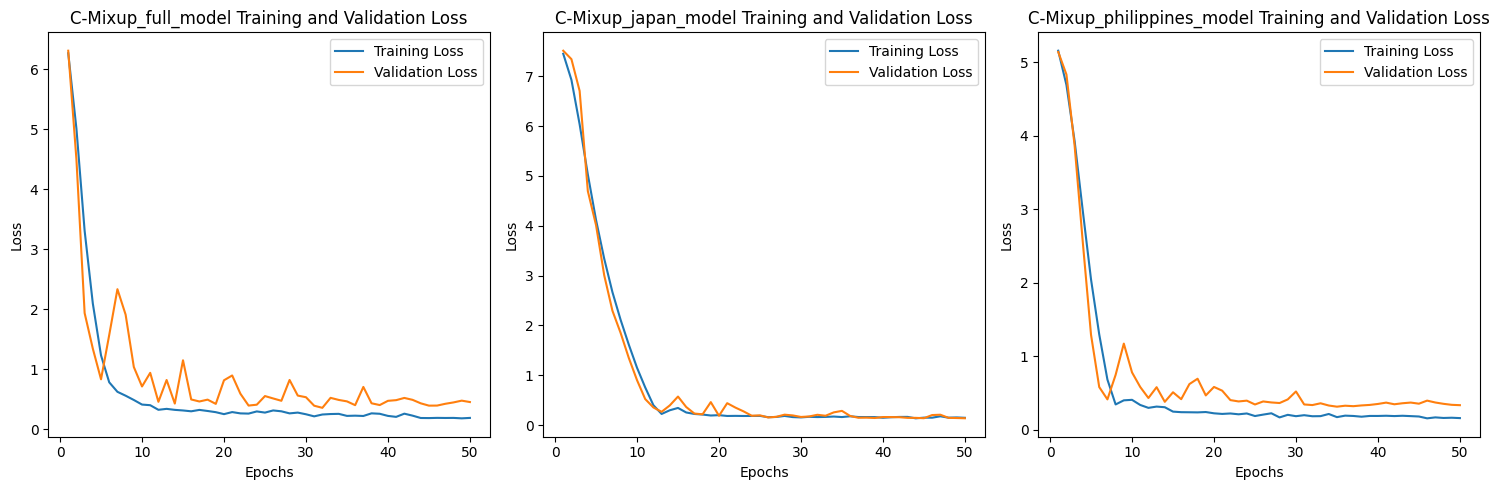

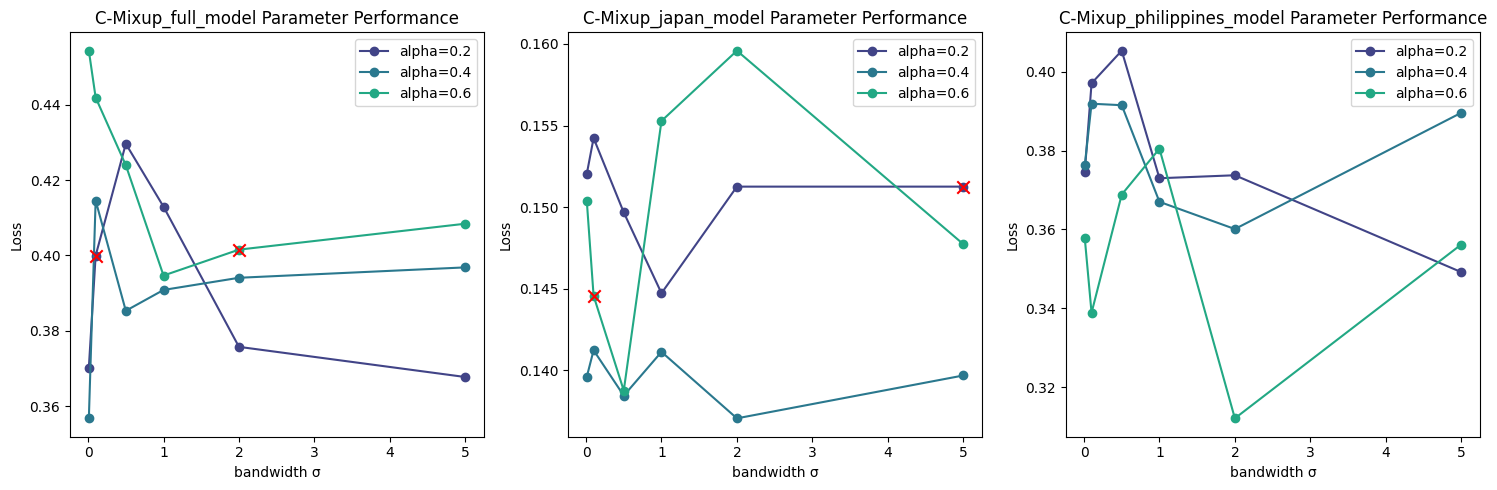

In [ ]:
def plot_training_losses(modelNames: List[str]):
    fig, axs = plt.subplots(1, len(modelNames), figsize=(15, 5))
    for i, modelName in enumerate(modelNames):
        checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=False)
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
        epochs = range(1, len(train_losses) + 1)
        axs[i].plot(epochs, train_losses, label='Training Loss')
        axs[i].plot(epochs, val_losses, label='Validation Loss')
        axs[i].set_title(f'{modelName} Training and Validation Loss')
        axs[i].set_xlabel('Epochs')
        axs[i].set_ylabel('Loss')
        axs[i].legend()
    plt.tight_layout()
    plt.show()

def plot_params_losses(modelNames: List[str]):
    fig, axs = plt.subplots(1, len(modelNames), figsize=(15, 5))
    if len(modelNames) == 1:
        axs = [axs]

    for i, modelName in enumerate(modelNames):
        checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=False)
        
        alpha_dict = {}
        for param, loss in checkpoint['params_losses']:
            sigma = param[0]
            alpha = param[1]
            loss = min(loss)
            if loss > 1:
                loss = np.nan

            if alpha not in alpha_dict:
                alpha_dict[alpha] = {"sigma": [], "loss": []}
            alpha_dict[alpha]["sigma"].append(sigma)
            alpha_dict[alpha]["loss"].append(loss)

        for alpha, vals in alpha_dict.items():
            sorted_pairs = sorted(zip(vals["sigma"], vals["loss"]))
            sigmas, losses = zip(*sorted_pairs)

            # Interpolate over NaNs for the drawn line, but mark them with an X
            losses_series = pd.Series(losses)
            losses_interpolated = losses_series.interpolate()
            nan_mask = losses_series.isna()

            axs[i].plot(sigmas, losses_interpolated,
                        marker='o', label=f'alpha={alpha}',
                        color=plt.cm.viridis(alpha))
            # Mark the NaN positions with an X so it's clear they were missing
            axs[i].scatter([s for s, m in zip(sigmas, nan_mask) if m],
                           [l for l, m in zip(losses_interpolated, nan_mask) if m],
                           marker='x', color='red', zorder=5, s=80)

        axs[i].set_xlabel('bandwidth σ')
        axs[i].set_ylabel('Loss')
        axs[i].set_title(f'{modelName} Parameter Performance')
        axs[i].legend()

    plt.tight_layout()
    plt.show()



plot_training_losses(["C-Mixup_full_model","C-Mixup_japan_model","C-Mixup_philippines_model"])
plot_params_losses(["C-Mixup_full_model","C-Mixup_japan_model","C-Mixup_philippines_model"])